# SUPG advection-diffusion-reaction of a rotating pulse in a rectangle

Donea, J. & Huerta, A. (2003). *Finite Element Methods for Flow Problems*. $\S 5.6.2$

$$
\mathbb{S}_u
\begin{cases}
\Omega = [0, 1] \times [0, 1] \\
u_0(x) = 0 \\
u_{\text{D}}=0 \\
\textbf{a} = (L_y/2-y)\textbf{e}_x + (x-L_x/2)\textbf{e}_y \\
\mathsf{D}=D\mathsf{I} \\
R = 0 \\ 
J(x,y,t) = e^{-t^{10}}\cos(\pi/2\sqrt{x^2+y^2})\text{H}(1-\sqrt{x^2+y^2})\\
\end{cases}
$$

In [ ]:
import numpy as np
from ufl import SpatialCoordinate, as_vector
from lucifex.mesh import rectangle_mesh
from lucifex.fem import Constant, Function
from lucifex.fdm import (
    BE, CN, advective_timestep, 
    FiniteDifference, FunctionSeries, ConstantSeries, finite_difference_order,
)
from lucifex.solver import ibvp , BoundaryConditions, evaluation, extrema
from lucifex.sim import Simulation, run
from lucifex.plt import (
    plot_streamlines, plot_line, save_figure, 
    plot_colormap, plot_colormap_multifigure,
)
from lucifex.pde.advection_diffusion import advection_diffusion_reaction

def source_amplitude(t) -> float:
    return np.exp(-float(t)**10)

def create_simulation(
    tau: str | None,
    Lx: float, 
    Ly: float,
    Nx: int,
    Ny: int,
    dt: float,
    d: float,
    D_adv: FiniteDifference,
    D_diff: FiniteDifference,
    D_src: FiniteDifference,
) -> Simulation:
    order = finite_difference_order(D_adv, D_diff, D_src)
    mesh = rectangle_mesh(Lx, Ly, Nx, Ny)
    radius = lambda x: np.sqrt(x[0]**2 + x[1]**2)
    t = ConstantSeries(mesh, name='t', ics=0.0)
    dt = Constant(mesh, dt, name='dt')
    x = SpatialCoordinate(mesh)
    a = as_vector((0.5 * Ly -x[1], x[0] - 0.5 * Lx))
    d = Constant(mesh, d, name='d')
    u = FunctionSeries(
        (mesh, 'P', 1), 
        name='u', 
        order=order, 
        store=1, 
        ics=0.0,
    )
    uMinMax = ConstantSeries(
        mesh, 
        name='uMinMax', 
        order=order,
        shape=(2,),
        store=1,
    )
    jt = ConstantSeries(
        mesh, 
        name='jt', 
        order=order,
        store=1,
        ics=source_amplitude(0.0),
    )
    jxy = Function(
        (mesh, 'P', 1),
        lambda x: 0.0 + np.cos(0.5 * np.pi * radius(x)) * (radius(x) <= 1.0), 
        name='jxy',   
    )
    jt_solver = evaluation(jt, source_amplitude, future=True)(t[1])
    bcs = BoundaryConditions(
        ('dirichlet', lambda x: x[0], 0.0),
        ('dirichlet', lambda x: x[0] - Lx, 0.0),
        ('dirichlet', lambda x: x[1], 0.0),
        ('dirichlet', lambda x: x[1] - Ly, 0.0),
    )
    u_solver = ibvp(advection_diffusion_reaction, bcs=bcs)(
        u, dt, a, d, j=D_src(jt) * jxy, D_adv=D_adv, D_diff=D_diff, tau=tau,
    )
    uMinMax_solver = evaluation(uMinMax, extrema)(u[0])
    solvers = (jt_solver, u_solver, uMinMax_solver)
    auxiliary = (('a', a), d, jxy)
    return Simulation(solvers, t, dt, auxiliary)


Lx = 1.0
Ly = 1.0
Nx = 40
Ny = 40
hx = Lx / Nx
hy = Ly / Ny
hMin = min(hx, hx)

d = 1e-5
aMax = np.sqrt(Lx**2 + Ly**2)
courant = 1.0
dt = advective_timestep(aMax, hMin, courant)

D_adv = CN
D_diff = CN
D_src = BE

tau_opts = ('coth', 'shakib', 'codina', 'transient', None) 
simulations: dict[None | str, Simulation] = {}

for tau in tau_opts:
    simulations[tau] = create_simulation(
        tau, Lx, Ly, Nx, Ny, dt, d, D_adv, D_diff, D_src,
    )

n_stop = 300
for tau in tau_opts:
    run(simulations[tau], n_stop)

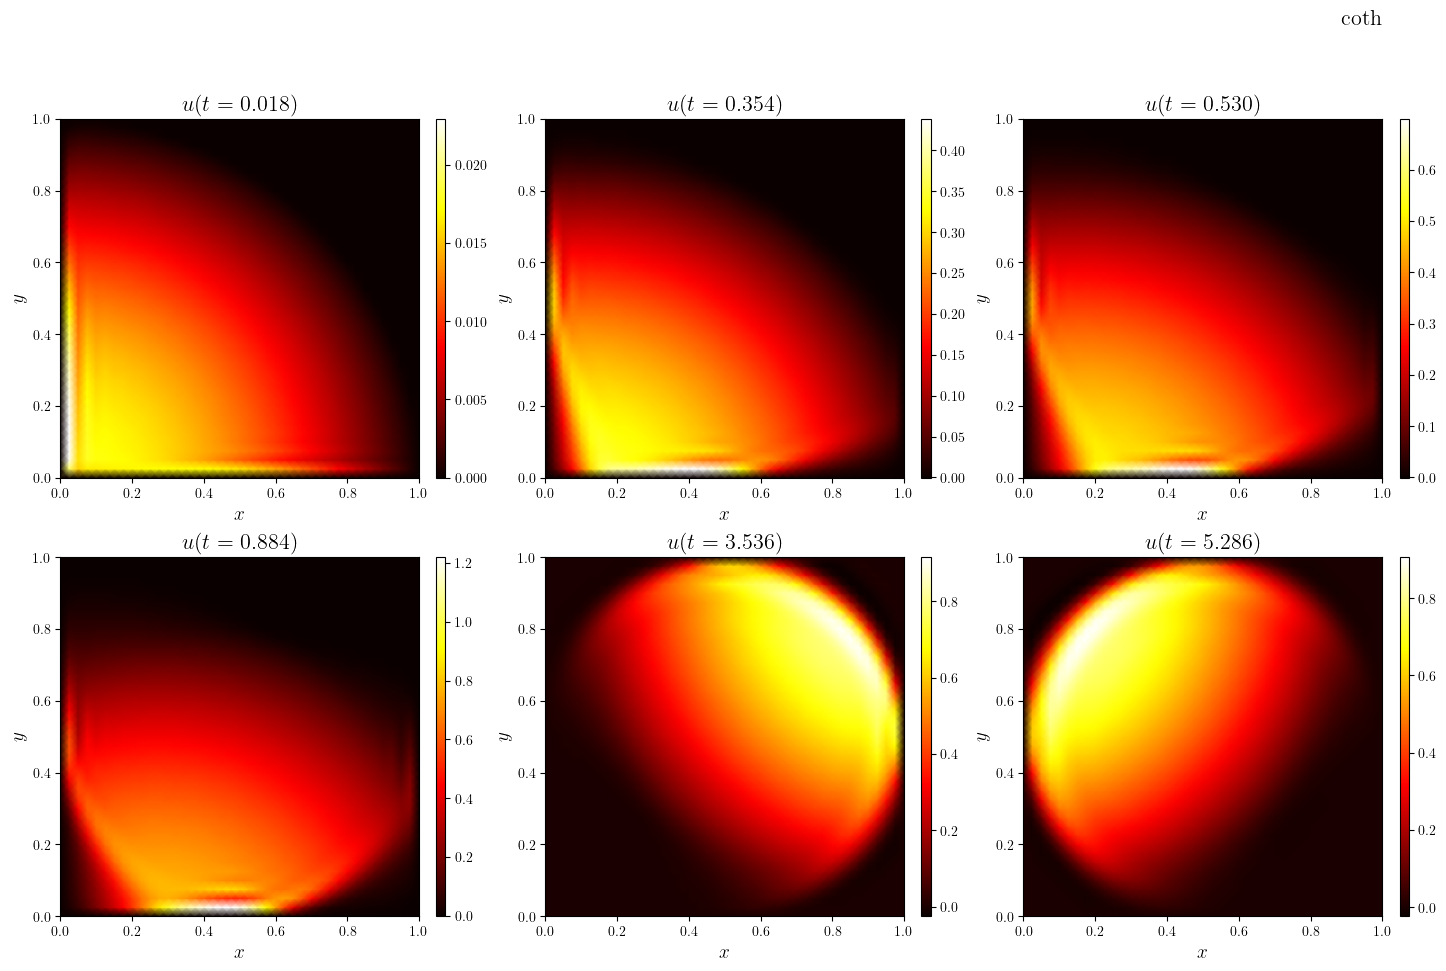

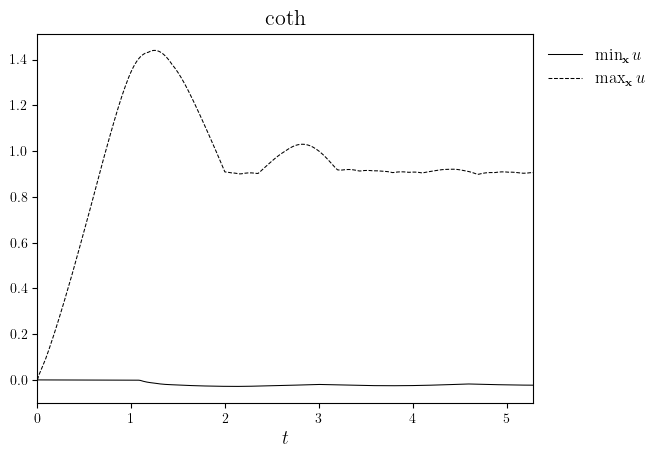

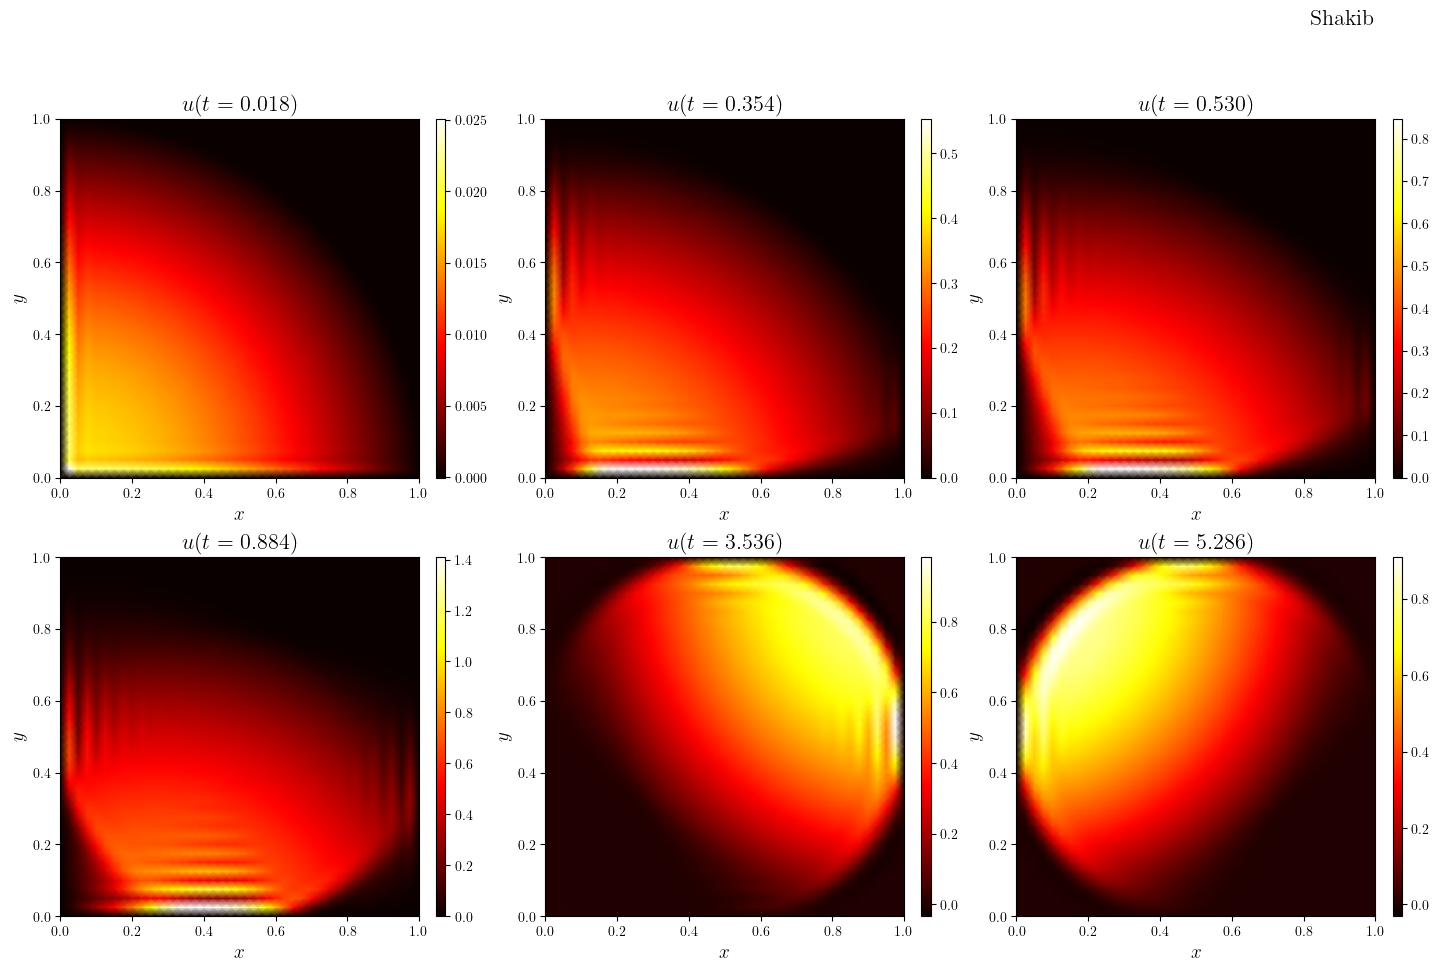

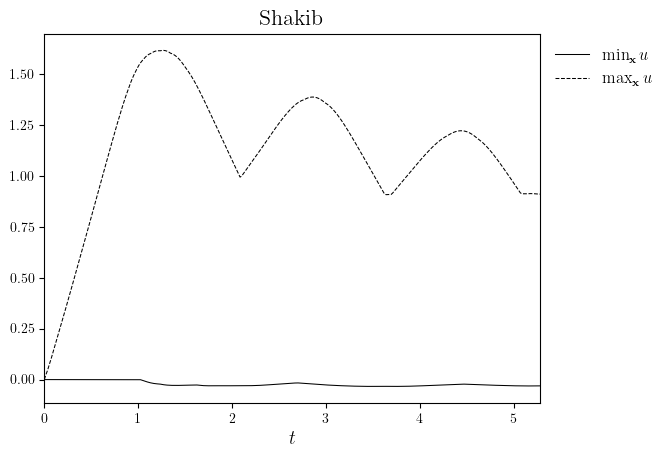

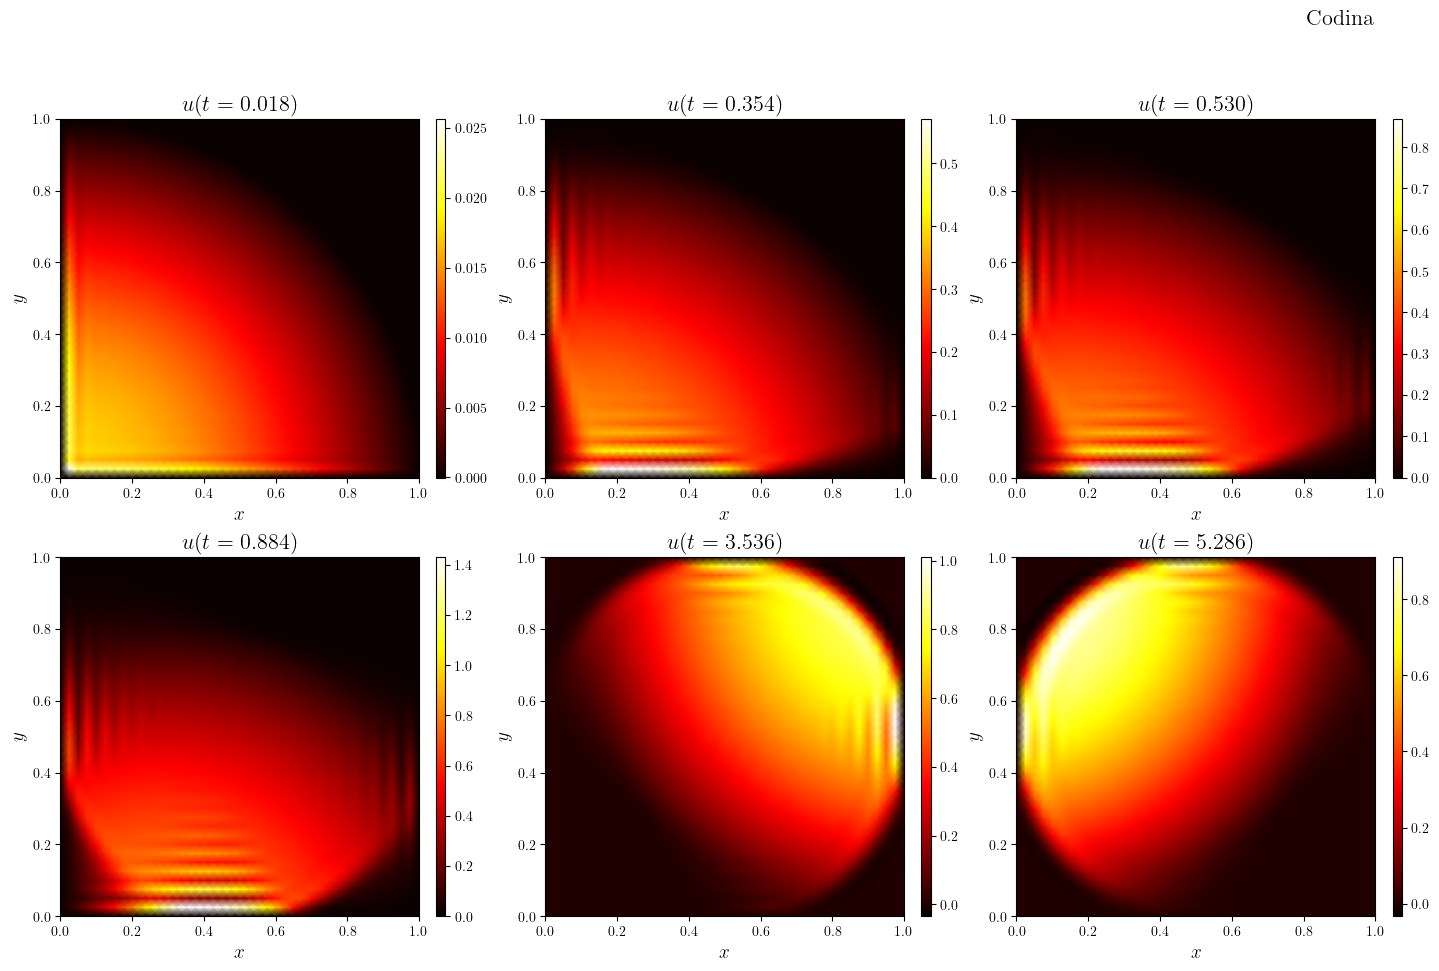

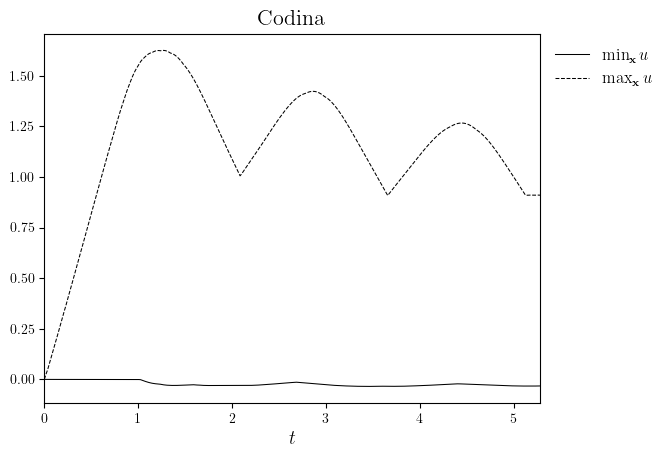

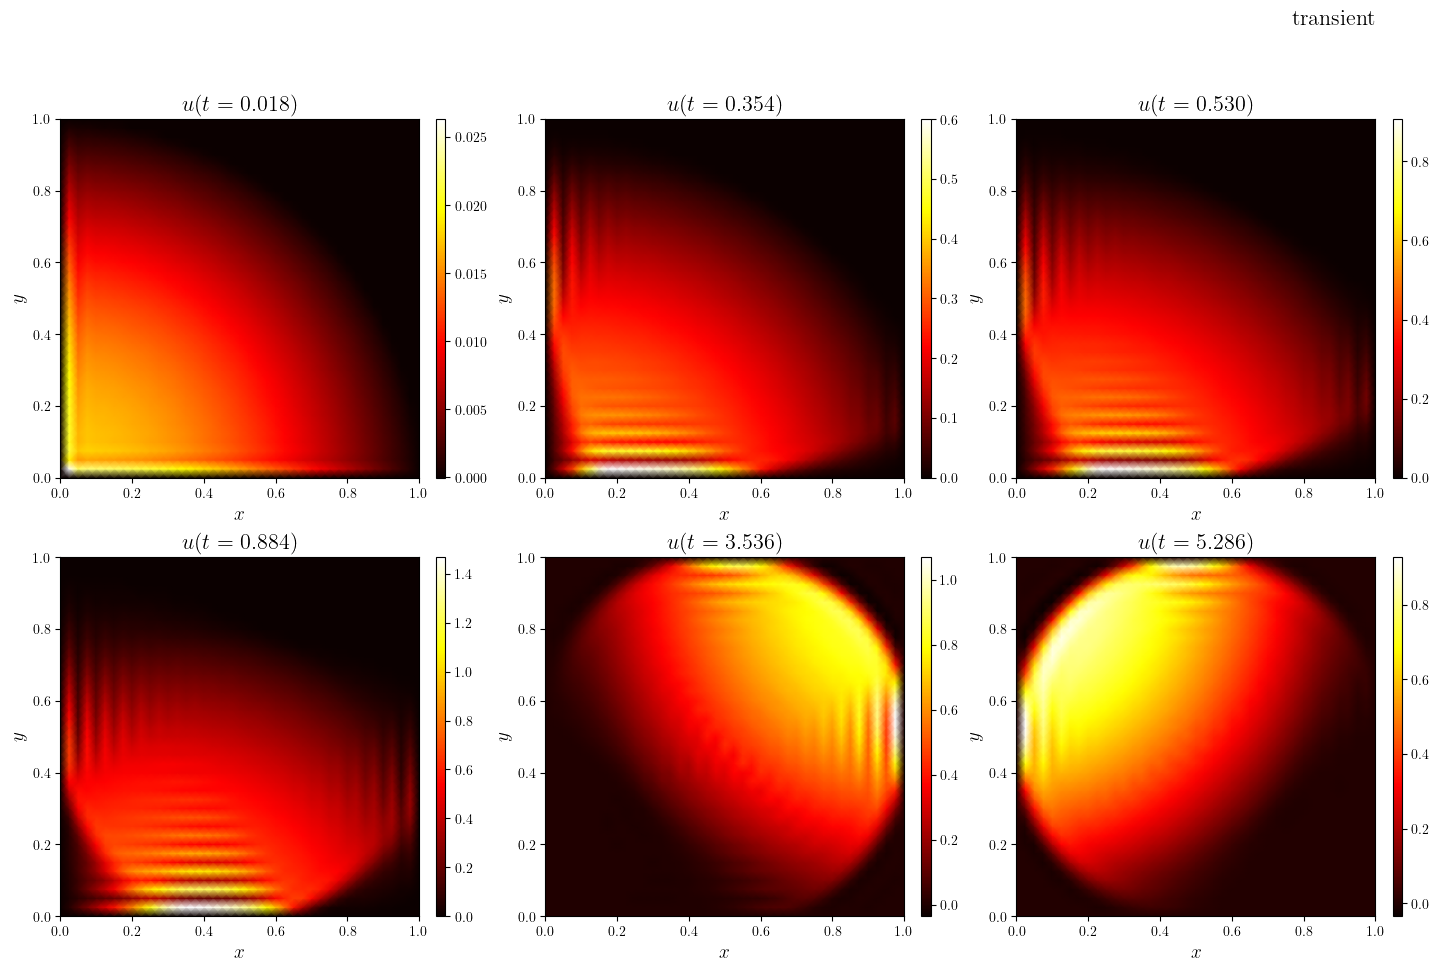

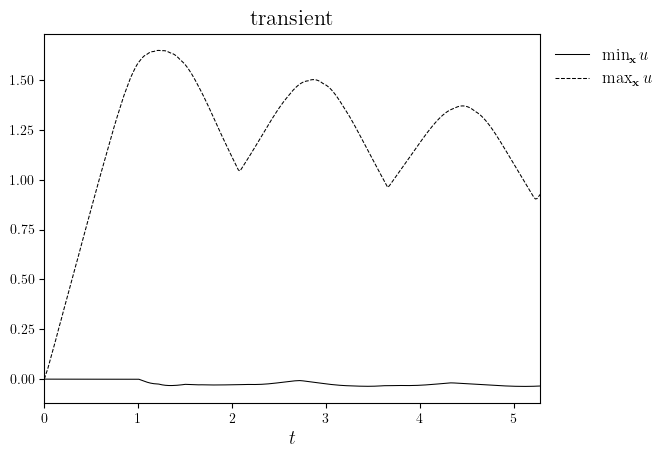

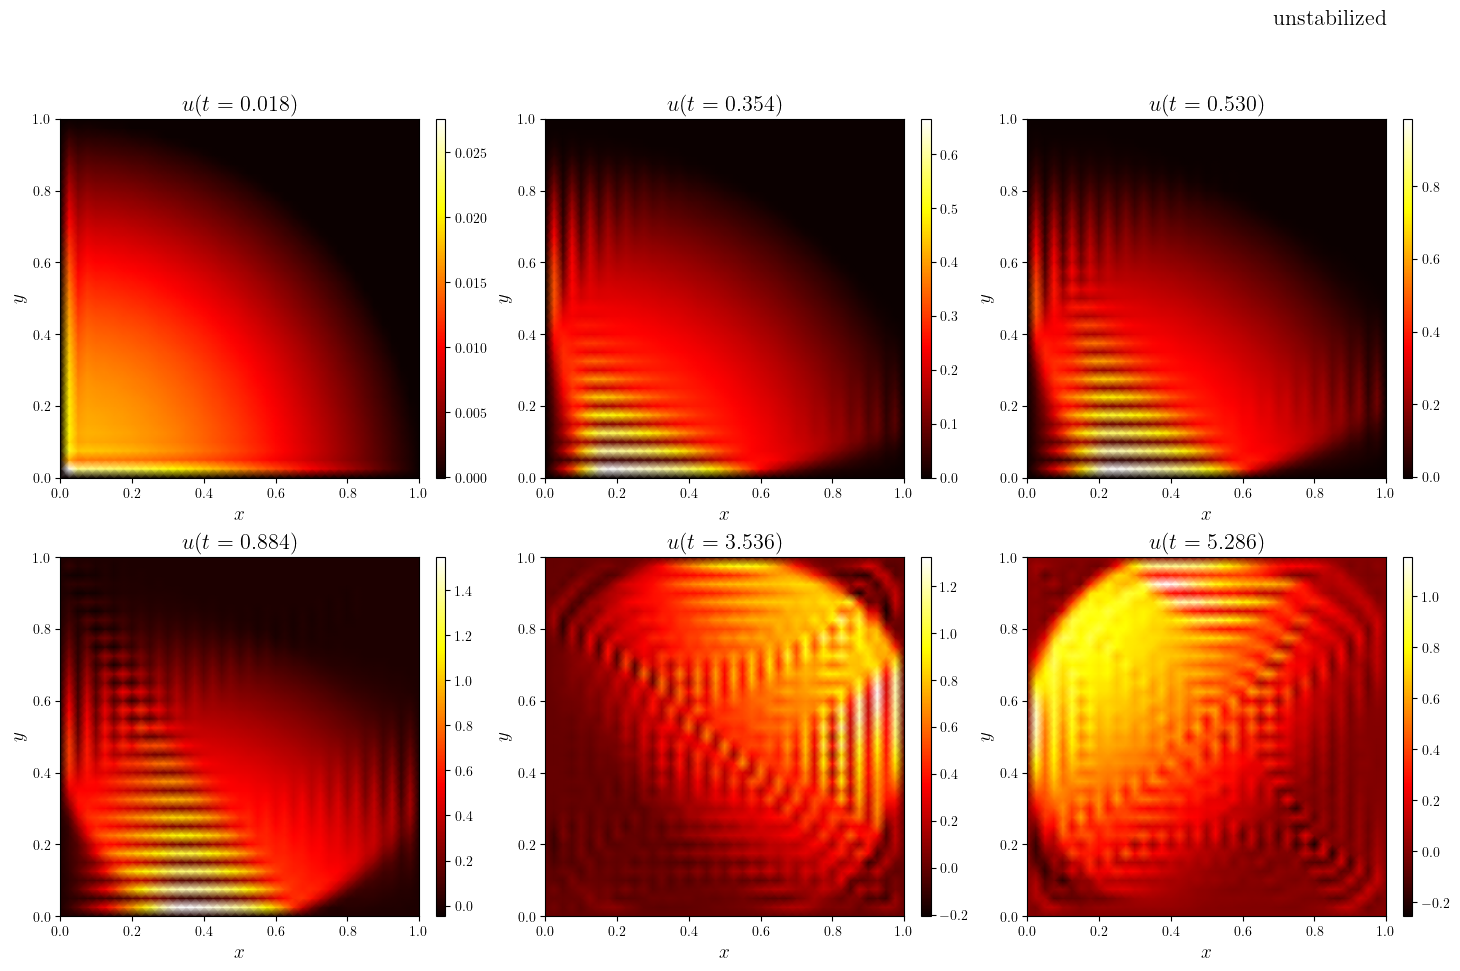

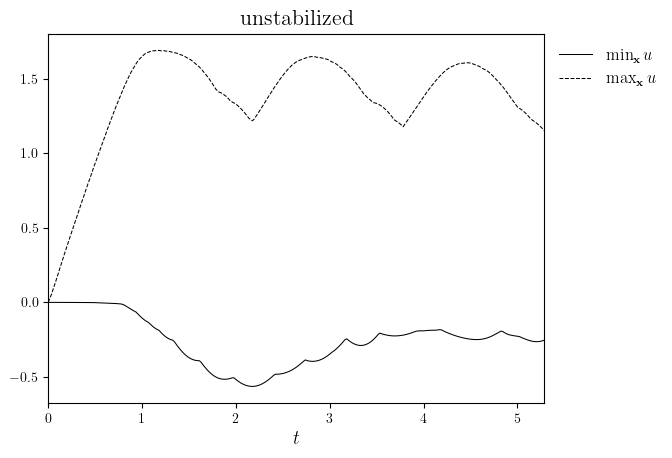

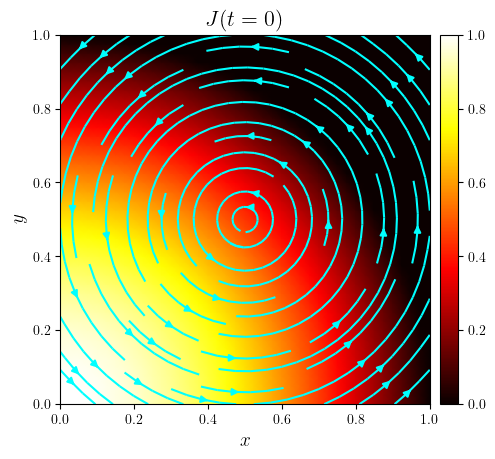

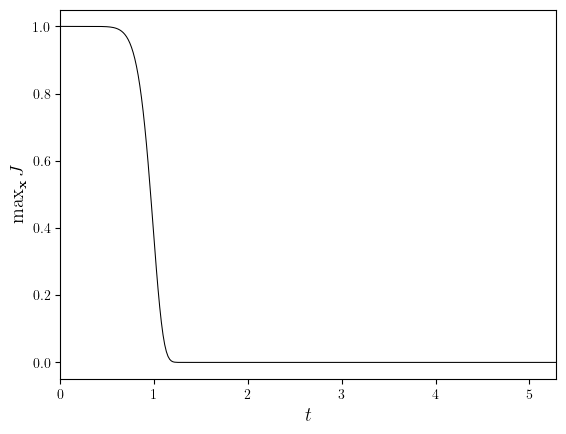

: 

In [ ]:
time_indices = (1, 20, 30, 50, 200, -1)

for tau in tau_opts:
    sim = simulations[tau]
    u, uMinMax = sim['u', 'uMinMax']
    if tau is None:
        tau_title = 'unstabilized'
    elif tau in ('shakib', 'codina'):
        tau_title = tau.capitalize()
    else:
        tau_title = str(tau)
    mfig, *_ = plot_colormap_multifigure(
        n_rows=2, 
        cbars=True, 
        suptitle=tau_title,
    )(
        [u.series[i] for i in time_indices],
        title=[f'$u(t={u.time_series[i]:.3f})$' for i in time_indices],
    )
    save_figure(f'u(x,y,t)_{tau}')(fig)
    fig, ax = plot_line(
        (uMinMax.time_series, uMinMax.value_series), 
        cyc='black',
        x_label='$t$',
        legend_labels=['$\min_{\\mathbf{x}}u$', '$\max_{\\mathbf{x}}u$'],
        title=tau_title,
    )
    save_figure(f'uMinMax(t)_{tau}', thumbnail=(tau == tau_opts[0]))(fig)
    if tau is None:
        a, jxy, jt = sim['a', 'jxy', 'jt']
        fig, ax = plot_colormap(jxy, title=f'$J(t=0)$')
        plot_streamlines(fig, ax, a, mesh=u.function_space.mesh, density=0.75, color='cyan')
        fig, ax = plot_line(
            (jt.time_series, jt.value_series),
            x_label='$t$',
            y_label='$\max_{\\mathbf{x}}J$',
        )